# Tarea : Segmentación en Sklearn con QDA

**Autores:** Julio Lucero / Agostina Squillari

In [30]:
import sys
import cv2
import numpy as np
import imageio as iio
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# Módulo propio de segmentación
from segmentacion_hsv import (
    segmentar_frame_escenario1,
    HSV_ROJO_LO1, HSV_ROJO_HI1,
    HSV_ROJO_LO2, HSV_ROJO_HI2,
    HSV_AZUL_LO,  HSV_AZUL_HI,
    COLOR_MARCA, COLOR_LINEA, COLOR_FONDO
)

## 1. Carga de imágenes etiquetadas manualmente

/var/folders/xc/p7wlz0j52ljblkz__vjkjkn00000gn/T/ipykernel_44200/3734883818.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imNp     = iio.imread('imagen_original.png')
/var/folders/xc/p7wlz0j52ljblkz__vjkjkn00000gn/T/ipykernel_44200/3734883818.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  markImg  = iio.imread('imagen_marcada.png')


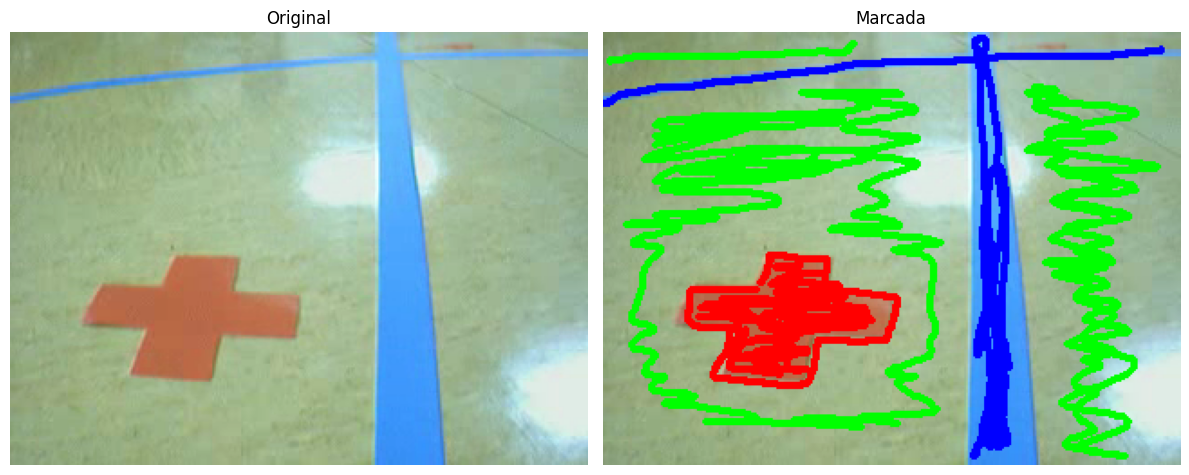

In [31]:
imNp     = iio.imread('imagen_original.png')
markImg  = iio.imread('imagen_marcada.png')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(imNp);    axs[0].set_title('Original');  axs[0].axis('off')
axs[1].imshow(markImg); axs[1].set_title('Marcada');   axs[1].axis('off')
plt.tight_layout(); plt.show()

## 2. Extracción de píxeles etiquetados

In [32]:
mask_marca = (markImg[:,:,0]==255)&(markImg[:,:,1]==0  )&(markImg[:,:,2]==0  )
mask_fondo = (markImg[:,:,0]==0  )&(markImg[:,:,1]==255)&(markImg[:,:,2]==0  )
mask_linea = (markImg[:,:,0]==0  )&(markImg[:,:,1]==0  )&(markImg[:,:,2]==255)

data_marca = imNp[mask_marca]
data_fondo = imNp[mask_fondo]
data_linea = imNp[mask_linea]

print(f'Píxeles marca (rojo): {len(data_marca)}')
print(f'Píxeles fondo (verde): {len(data_fondo)}')
print(f'Píxeles línea (azul): {len(data_linea)}')

Píxeles marca (rojo): 4433
Píxeles fondo (verde): 13963
Píxeles línea (azul): 4151


## 3. Análisis de color en espacio RGB

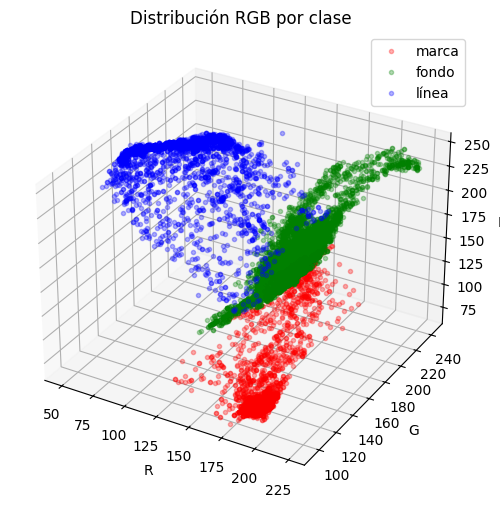

In [33]:
fig = plt.figure(figsize=(8,6))
ax  = fig.add_subplot(projection='3d')
ax.plot(data_marca[:,0], data_marca[:,1], data_marca[:,2], 'r.', alpha=0.3, label='marca')
ax.plot(data_fondo[:,0], data_fondo[:,1], data_fondo[:,2], 'g.', alpha=0.3, label='fondo')
ax.plot(data_linea[:,0], data_linea[:,1], data_linea[:,2], 'b.', alpha=0.3, label='línea')
ax.set_xlabel('R'); ax.set_ylabel('G'); ax.set_zlabel('B')
ax.legend(); plt.title('Distribución RGB por clase'); plt.show()

## 4. Análisis en espacio HSV

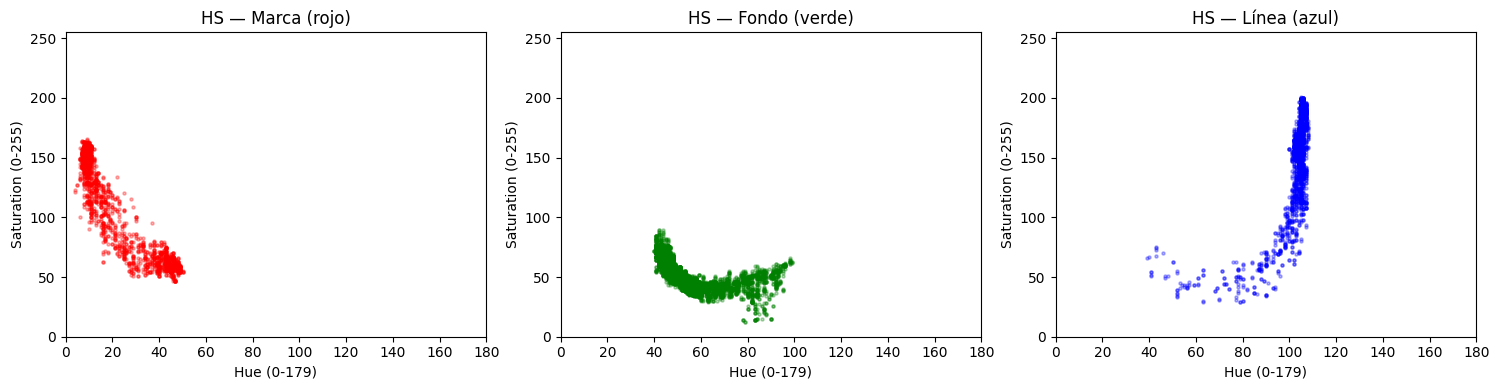

Marca: H=[4,50]  S=[47,166]  V=[120,221]
Fondo: H=[40,99]  S=[12,89]  V=[139,244]
Línea: H=[39,108]  S=[29,201]  V=[141,255]


In [35]:
def rgb_a_hsv_pixeles(data_rgb):
    
    img_tmp = data_rgb.reshape(1, -1, 3)
    hsv_tmp = cv2.cvtColor(img_tmp, cv2.COLOR_RGB2HSV)
    return hsv_tmp.reshape(-1, 3)

hsv_marca = rgb_a_hsv_pixeles(data_marca)
hsv_fondo = rgb_a_hsv_pixeles(data_fondo)
hsv_linea = rgb_a_hsv_pixeles(data_linea)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, datos, color, titulo in zip(
        axs,
        [hsv_marca, hsv_fondo, hsv_linea],
        ['r', 'g', 'b'],
        ['Marca (rojo)', 'Fondo (verde)', 'Línea (azul)']):
    ax.scatter(datos[:,0], datos[:,1], c=color, alpha=0.3, s=5)
    ax.set_xlabel('Hue (0-179)'); ax.set_ylabel('Saturation (0-255)')
    ax.set_title(f'HS — {titulo}')
    ax.set_xlim(0, 180); ax.set_ylim(0, 255)
plt.tight_layout(); plt.show()

for nombre, datos in [('Marca', hsv_marca), ('Fondo', hsv_fondo), ('Línea', hsv_linea)]:
    print(f'{nombre}: H=[{datos[:,0].min():.0f},{datos[:,0].max():.0f}]  '
          f'S=[{datos[:,1].min():.0f},{datos[:,1].max():.0f}]  '
          f'V=[{datos[:,2].min():.0f},{datos[:,2].max():.0f}]')

## 5. Librerias de Sklearn 

In [36]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import time


## 6. Preparación del dataset de entrenamiento con features HSV + RGB

In [37]:
def extraer_features(data_rgb):
    
    # HSV
    img_tmp = data_rgb.reshape(1, -1, 3).astype(np.uint8)
    hsv = cv2.cvtColor(img_tmp, cv2.COLOR_RGB2HSV).reshape(-1, 3).astype(np.float32)
    hsv[:, 0] /= 179.0   # H: 0-179 → 0-1
    hsv[:, 1] /= 255.0   # S: 0-255 → 0-1
    hsv[:, 2] /= 255.0   # V: 0-255 → 0-1
    
    # RGB normalizado
    rgb_norm = data_rgb.astype(np.float32) / 255.0
    
    # Concatenar HSV + RGB
    return np.hstack([hsv, rgb_norm])


# Extraer features por clase
feat_marca = extraer_features(data_marca)   # clase 1
feat_fondo = extraer_features(data_fondo)   # clase 0
feat_linea = extraer_features(data_linea)   # clase 2

# Labels
labels_marca = np.ones(len(feat_marca),  dtype=int)
labels_fondo = np.zeros(len(feat_fondo), dtype=int)
labels_linea = np.full(len(feat_linea),  2, dtype=int)

# Dataset completo
X_train = np.vstack([feat_marca, feat_fondo, feat_linea])
y_train = np.concatenate([labels_marca, labels_fondo, labels_linea])

print(f"Dataset de entrenamiento:")
print(f"  Total píxeles: {len(X_train)}")
print(f"  Clase 0 (fondo):  {(y_train==0).sum()} píxeles")
print(f"  Clase 1 (marca):  {(y_train==1).sum()} píxeles")
print(f"  Clase 2 (línea):  {(y_train==2).sum()} píxeles")
print(f"  Features por píxel: {X_train.shape[1]} [H, S, V, R, G, B]")

Dataset de entrenamiento:
  Total píxeles: 22547
  Clase 0 (fondo):  13963 píxeles
  Clase 1 (marca):  4433 píxeles
  Clase 2 (línea):  4151 píxeles
  Features por píxel: 6 [H, S, V, R, G, B]


## 7. Entrenamiento y evaluación del QDA

=== Reporte de clasificación QDA ===
                  precision    recall  f1-score   support

       Fondo (0)     0.9293    1.0000    0.9633     13963
Marca/Flecha (1)     1.0000    0.8046    0.8918      4433
       Línea (2)     1.0000    0.9525    0.9757      4151

        accuracy                         0.9529     22547
       macro avg     0.9764    0.9191    0.9436     22547
    weighted avg     0.9562    0.9529    0.9515     22547



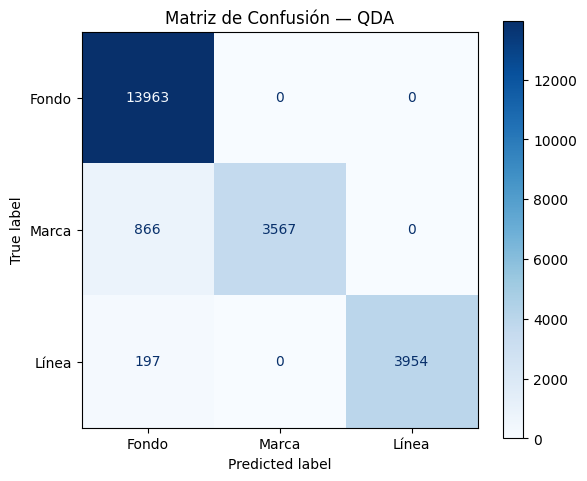

In [39]:
# Usar QDA como modelo definitivo
clf_qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
clf_qda.fit(X_train, y_train)

# Evaluación sobre los datos de entrenamiento (imagen etiquetada)
y_pred = clf_qda.predict(X_train)

print("=== Reporte de clasificación QDA ===")
print(classification_report(
    y_train, y_pred,
    target_names=['Fondo (0)', 'Marca/Flecha (1)', 'Línea (2)'],
    digits=4
))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fondo', 'Marca', 'Línea']
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — QDA')
plt.tight_layout()
plt.show()

In [41]:
PALETA_CLASES = np.array([
    [0,  255,  0],    # 0: fondo  — verde 
    [255,  0,  0],    # 1: marca  — rojo
    [0,  0, 255],    # 2: línea  — azul 
], dtype=np.uint8)

def limpiar_mascara(mask, kernel_size=3, iter_open=1, iter_close=2):
    
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    m = mask.astype(np.uint8) * 255
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  k, iterations=iter_open)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=iter_close)
    return m > 0

def segmentar_con_qda(rgb_frame, clf, alpha_overlay=0.55):
    
    h, w = rgb_frame.shape[:2]
    
    # 1. Extraer features de todos los píxeles del frame
    pixeles_rgb = rgb_frame.reshape(-1, 3)
    feats = extraer_features(pixeles_rgb)
    
    # 2. Predicción
    preds = clf.predict(feats).reshape(h, w)
    
    # 3. Limpieza morfológica por clase
    preds_limpio = np.zeros_like(preds)
    for clase, k_size, n_close in [(1, 3, 3), (2, 5, 4), (0, 3, 2)]:
        mask_clase = limpiar_mascara(preds == clase,
                                     kernel_size=k_size,
                                     iter_close=n_close)
        preds_limpio[mask_clase] = clase
    
    # 4. Colorización pura
    resultado_puro = PALETA_CLASES[preds_limpio]
    
    # 5. Overlay semi-transparente sobre original
    resultado_blend = cv2.addWeighted(
        rgb_frame.astype(np.uint8),
        1.0 - alpha_overlay,
        resultado_puro.astype(np.uint8),
        alpha_overlay,
        0
    )
    
    return resultado_puro, resultado_blend, preds_limpio



## 8. Procesado del vídeo con QDA


In [ ]:
VIDEO_ENTRADA    = 'video1.mp4'
VIDEO_SALIDA_PURO    = 'video1_qda_puro.mp4'
VIDEO_SALIDA_OVERLAY = 'video1_qda_overlay.mp4'
ALPHA_OVERLAY        = 0.50   

cap   = cv2.VideoCapture(VIDEO_ENTRADA)
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps   = cap.get(cv2.CAP_PROP_FPS) or 25
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Video: {ancho}×{alto}  {fps:.1f}fps  {total} frames')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer_puro    = cv2.VideoWriter(VIDEO_SALIDA_PURO,    fourcc, fps, (ancho, alto))
writer_overlay = cv2.VideoWriter(VIDEO_SALIDA_OVERLAY, fourcc, fps, (ancho, alto))

frames_muestra_qda = []
indices_muestra    = set([0, total//4, total//2, 3*total//4, total-1])

tiempos_frame = []

for i in range(total):
    ret, bgr = cap.read()
    if not ret:
        break
    
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    
    t0 = time.time()
    puro, overlay, _ = segmentar_con_qda(rgb, clf_qda, alpha_overlay=ALPHA_OVERLAY)
    tiempos_frame.append(time.time() - t0)
    
    writer_puro.write(cv2.cvtColor(puro,    cv2.COLOR_RGB2BGR))
    writer_overlay.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    
    if i in indices_muestra:
        frames_muestra_qda.append((rgb, puro, overlay))
    
    if (i+1) % 25 == 0:
        t_medio = np.mean(tiempos_frame[-25:]) * 1000
        print(f'  Frame {i+1:4d}/{total}  ({t_medio:.0f} ms/frame)')

cap.release()
writer_puro.release()
writer_overlay.release()

t_total = sum(tiempos_frame)
t_medio = np.mean(tiempos_frame) * 1000
print(f'\nVideos guardados:')
print(f'   {VIDEO_SALIDA_PURO}')
print(f'   {VIDEO_SALIDA_OVERLAY}')
print(f'\nTiempo total: {t_total:.1f}s  |  Medio: {t_medio:.0f}ms/frame  |  Equivalente: {1000/t_medio:.1f} FPS procesados')

Video: 320×240  100.0fps  1877 frames
  Frame   25/1877  (9 ms/frame)
  Frame   50/1877  (8 ms/frame)
  Frame   75/1877  (8 ms/frame)
  Frame  100/1877  (8 ms/frame)
  Frame  125/1877  (7 ms/frame)
  Frame  150/1877  (8 ms/frame)
  Frame  175/1877  (7 ms/frame)
  Frame  200/1877  (8 ms/frame)
  Frame  225/1877  (8 ms/frame)
  Frame  250/1877  (7 ms/frame)
  Frame  275/1877  (7 ms/frame)
  Frame  300/1877  (7 ms/frame)
  Frame  325/1877  (7 ms/frame)
  Frame  350/1877  (7 ms/frame)
  Frame  375/1877  (7 ms/frame)
  Frame  400/1877  (7 ms/frame)
  Frame  425/1877  (7 ms/frame)
  Frame  450/1877  (8 ms/frame)
  Frame  475/1877  (7 ms/frame)
  Frame  500/1877  (9 ms/frame)
  Frame  525/1877  (9 ms/frame)
  Frame  550/1877  (7 ms/frame)
  Frame  575/1877  (7 ms/frame)
  Frame  600/1877  (7 ms/frame)
  Frame  625/1877  (7 ms/frame)
  Frame  650/1877  (7 ms/frame)
  Frame  675/1877  (7 ms/frame)
  Frame  700/1877  (7 ms/frame)
  Frame  725/1877  (7 ms/frame)
  Frame  750/1877  (7 ms/frame)
  